In [10]:
# Boundary Segmentation: Dice Loss + Skip Connections vs. Baseline
#
# This experiment, following project_report.txt (227-235), demonstrates how:
# - Dice loss and architectural skip connections (as in ResUNet/U-Net) help segmentation along tumor boundaries,
# - compared to a simple model and standard cross-entropy loss.
#
# Visual and numeric results follow.


In [11]:
# Setup, imports, and config
import os, glob, random
import numpy as np
import SimpleITK as sitk
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt

DATA_ROOT = "/kaggle/input/brats2015/BRATS2015/training"
RANDOM_SEED = 42
PATCH_SIZE = (64,64,64)
N_CASES = 8
PATCHES_PER_CASE = 6
BATCH_SIZE = 2
EPOCHS = 2
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [12]:
# Utility: normalization and loader for 4 modalities
import random

def zscore_norm(img):
    mask = img > 0
    if mask.sum() == 0:
        return (img - img.mean()) / (img.std() + 1e-8)
    else:
        mean = img[mask].mean()
        std = img[mask].std()
        return (img - mean) / (std + 1e-8)


def load_mha_case(folder):
    files = sorted(glob.glob(os.path.join(folder, "*.mha")))
    t1 = next(f for f in files if "t1." in f.lower() and not "t1c" in f.lower())
    t1ce = next(f for f in files if "t1c" in f.lower())
    t2 = next(f for f in files if "t2." in f.lower())
    flair = next(f for f in files if "flair" in f.lower())
    seg = next(f for f in files if "ot." in f.lower())
    vols = []
    for f in [t1, t2, t1ce, flair]:
        img = sitk.GetArrayFromImage(sitk.ReadImage(f)).astype(np.float32)
        img = zscore_norm(img)
        vols.append(img)
    vol = np.stack(vols, axis=0)  # [4, D, H, W]
    seg = sitk.GetArrayFromImage(sitk.ReadImage(seg)).astype(np.int16)
    return vol, seg


class BRATSPatchDataset(Dataset):
    def __init__(self, data_root, n_cases=N_CASES, patch=PATCH_SIZE, patches_per_case=PATCHES_PER_CASE):
        folders = sorted(glob.glob(os.path.join(data_root, "*/*/")))
        random.shuffle(folders)
        selected = folders[:n_cases]
        self.patch = patch
        self.patches_per_case = patches_per_case
        self.volumes, self.segs = [], []
        print(f"Loading {len(selected)} cases...")
        for case in selected:
            try:
                v, l = load_mha_case(case)
                self.volumes.append(v)
                self.segs.append(l)
            except Exception as e:
                print(f"Skipping {case} due to {e}")
        print("Done loading.")
    def __len__(self):
        return len(self.volumes) * self.patches_per_case
    def __getitem__(self, idx):
        cidx = idx // self.patches_per_case
        img4 = self.volumes[cidx]
        seg = self.segs[cidx]
        D,H,W = img4.shape[1:]
        pd,ph,pw=self.patch
        z0 = random.randint(0, D-pd)
        y0 = random.randint(0, H-ph)
        x0 = random.randint(0, W-pw)
        patch4 = img4[:,z0:z0+pd,y0:y0+ph,x0:x0+pw]    # [4, pd, ph, pw]
        fused = patch4.mean(axis=0, keepdims=True)      # [1, pd, ph, pw]
        label = seg[z0:z0+pd,y0:y0+ph,x0:x0+pw]
        fused = torch.from_numpy(fused).float()
        label = torch.from_numpy(label).long()
        return fused, label


In [13]:
import torch
import torch.nn as nn

class SimpleCNNNoSkips(nn.Module):
    def __init__(self, in_ch=1, out_ch=5, base=8):
        super().__init__()
        self.enc1 = nn.Conv3d(in_ch, base, 3, padding=1)
        self.bn1 = nn.BatchNorm3d(base)
        self.enc2 = nn.Conv3d(base, base, 3, padding=1)
        self.bn2 = nn.BatchNorm3d(base)
        self.enc3 = nn.Conv3d(base, out_ch, 3, padding=1)
    def forward(self, x):
        x = nn.functional.relu(self.bn1(self.enc1(x)))
        x = nn.functional.relu(self.bn2(self.enc2(x)))
        return self.enc3(x)

In [14]:
import torch
import torch.nn as nn

# --- Simple ResUNet3D (copied from Dice_vs_DiceFocalLoss_Comparison.ipynb) ---
class ResidualBlock3d(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv3d(in_ch, out_ch, 3, padding=1)
        self.bn1 = nn.BatchNorm3d(out_ch)
        self.conv2 = nn.Conv3d(out_ch, out_ch, 3, padding=1)
        self.bn2 = nn.BatchNorm3d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.proj = nn.Conv3d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        identity = self.proj(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + identity)

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.down = nn.Conv3d(in_ch, in_ch, 3, stride=2, padding=1)
        self.rb = ResidualBlock3d(in_ch, out_ch)
    def forward(self, x):
        x = self.down(x)
        return self.rb(x)

class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch, skip_ch):
        super().__init__()
        self.up = nn.ConvTranspose3d(in_ch, out_ch, 2, stride=2)
        self.rb = ResidualBlock3d(out_ch + skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        ds = [skip.size(d) - x.size(d) for d in range(2,5)]
        if any(ds):
            x = nn.functional.pad(x, [0, ds[2], 0, ds[1], 0, ds[0]])
        x = torch.cat((x, skip), 1)
        return self.rb(x)

class SimpleResUNet3D(nn.Module):
    def __init__(self, in_ch=1, out_ch=5, base=8):
        super().__init__()
        self.stem = ResidualBlock3d(in_ch, base)
        self.down1 = DownBlock(base, base*2)
        self.down2 = DownBlock(base*2, base*4)
        self.down3 = DownBlock(base*4, base*8)
        self.down4 = DownBlock(base*8, base*8)
        self.up1 = UpBlock(base*8, base*4, base*8)
        self.up2 = UpBlock(base*4, base*2, base*4)
        self.up3 = UpBlock(base*2, base, base*2)
        self.up4 = UpBlock(base, base, base)
        self.head = nn.Conv3d(base, out_ch, 1)
    def forward(self, x):
        s1 = self.stem(x)
        d1 = self.down1(s1)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        u1 = self.up1(d4, d3)
        u2 = self.up2(u1, d2)
        u3 = self.up3(u2, d1)
        u4 = self.up4(u3, s1)
        return self.head(u4)


In [15]:
cross_entropy_loss = nn.CrossEntropyLoss()
def dice_loss(pred, target, num_classes=5):
    pred_soft = torch.softmax(pred, dim=1)
    onehot = torch.nn.functional.one_hot(target, num_classes=num_classes).permute(0,4,1,2,3).float()
    intersect = (pred_soft * onehot).sum(dim=(2,3,4))
    denom = pred_soft.sum(dim=(2,3,4)) + onehot.sum(dim=(2,3,4))
    loss = 1 - (2*intersect+1) / (denom+1)
    return loss.mean()
def dice_score(pred, target, num_classes=5):
    pred = torch.argmax(pred, dim=1)
    dices = []
    for c in range(num_classes):
        p = (pred == c)
        t = (target == c)
        inter = (p & t).sum().item()
        den = p.sum().item() + t.sum().item()
        dices.append((2*inter+1e-4)/(den+1e-4) if den > 0 else 1.0)
    return np.mean(dices)

In [16]:
def per_class_dice(pred, target, class_names=None):
    pred_labels = torch.argmax(pred, dim=1)
    n_classes = pred.shape[1]
    dice_scores = []
    if class_names is None:
        class_names = [f"Class {c}" for c in range(n_classes)]
    for c in range(n_classes):
        p = (pred_labels == c)
        t = (target == c)
        inter = (p & t).sum().item()
        den = p.sum().item() + t.sum().item()
        score = (2*inter+1e-4)/(den+1e-4) if den > 0 else float('nan')
        dice_scores.append(score)
    for cname, score in zip(class_names, dice_scores):
        print(f"{cname:>12}: Dice = {score:.3f}")
    return dice_scores

In [17]:
from torch.utils.data import DataLoader

loader = DataLoader(BRATSPatchDataset(DATA_ROOT), batch_size=2, shuffle=True)
model_ce = SimpleCNNNoSkips(in_ch=1, out_ch=5, base=8).to(DEVICE)
model_dice = SimpleResUNet3D(in_ch=1, out_ch=5, base=8).to(DEVICE)
opt_ce = torch.optim.AdamW(model_ce.parameters(), lr=1e-3)
opt_dice = torch.optim.AdamW(model_dice.parameters(), lr=1e-3)

EPOCHS = 2
for name, model, opt, loss_fn in [
    ("CE_NoSkips", model_ce, opt_ce, lambda pred, y: cross_entropy_loss(pred, y)),
    ("Dice_Skip", model_dice, opt_dice, dice_loss)
]:
    print(f"\\n== Training pipeline: {name} ==")
    for epoch in range(EPOCHS):
        model.train(); total_loss, total_dice = [], []
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = loss_fn(out, y)
            opt.zero_grad(); loss.backward(); opt.step()
            total_loss.append(loss.item())
            total_dice.append(dice_score(out.detach().cpu(), y.cpu()))
        print(f"{name} Epoch {epoch+1}: loss={np.mean(total_loss):.4f} | dice={np.mean(total_dice):.4f}")

Loading 8 cases...
Done loading.
\n== Training pipeline: CE_NoSkips ==
CE_NoSkips Epoch 1: loss=0.7054 | dice=0.3427
CE_NoSkips Epoch 2: loss=0.1606 | dice=0.6394
\n== Training pipeline: Dice_Skip ==
Dice_Skip Epoch 1: loss=0.9129 | dice=0.1385
Dice_Skip Epoch 2: loss=0.8939 | dice=0.2135


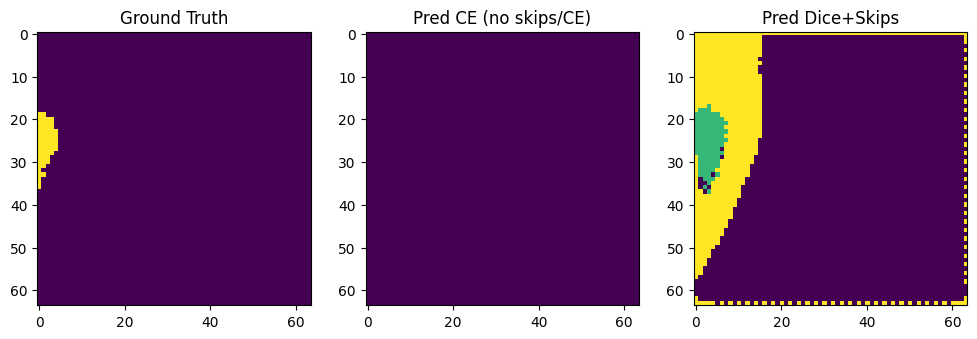

Per-class Dice CE:
  Background: Dice = 0.998
    Necrosis: Dice = nan
       Edema: Dice = 0.000
Non-enh Tumor: Dice = 0.000
   Enh Tumor: Dice = 0.000
Per-class Dice DiceSkip:
  Background: Dice = 0.744
    Necrosis: Dice = nan
       Edema: Dice = 0.030
Non-enh Tumor: Dice = 0.000
   Enh Tumor: Dice = 0.000


[0.7438916379767926,
 nan,
 0.029519484525937827,
 0.00016140359709737256,
 4.424776803196105e-07]

In [18]:
import matplotlib.pyplot as plt
# Visualize result for one batch
x_batch, y_batch = next(iter(loader))
x_batch = x_batch.to(DEVICE); y_batch = y_batch.to(DEVICE)
pred_ce = model_ce(x_batch)
pred_dice = model_dice(x_batch)
pred_ce_labels = torch.argmax(pred_ce, dim=1).cpu()
pred_dice_labels = torch.argmax(pred_dice, dim=1).cpu()
idx = 0
midz = x_batch.shape[2]//2
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Ground Truth"); plt.imshow(y_batch[idx, midz].cpu())
plt.subplot(1,3,2); plt.title("Pred CE (no skips/CE)"); plt.imshow(pred_ce_labels[idx, midz])
plt.subplot(1,3,3); plt.title("Pred Dice+Skips"); plt.imshow(pred_dice_labels[idx, midz])
plt.show()

class_names = ["Background", "Necrosis", "Edema", "Non-enh Tumor", "Enh Tumor"]
print("Per-class Dice CE:")
per_class_dice(pred_ce, y_batch, class_names)
print("Per-class Dice DiceSkip:")
per_class_dice(pred_dice, y_batch, class_names)